In [7]:
!pip install scikit-image pydicom opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt
import pydicom
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Dataset paths
dataset_path = "../input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/"
train_images_dir = os.path.join(dataset_path, "stage_2_train/")
train_csv = os.path.join(dataset_path, "stage_2_train.csv")

# Load and preprocess train.csv
df = pd.read_csv(train_csv)
# Create 'id' and 'subtype'
df['id'] = df['ID'].apply(lambda st: "ID_" + st.split('_')[1])
df['subtype'] = df['ID'].apply(lambda st: st.split('_')[2])
df = df[["id", "subtype", "Label"]]

# Remove duplicates and fill missing values
df = df.drop_duplicates(subset=['id', 'subtype'])
df['Label'] = df['Label'].fillna(0)

# Pivot the data
df_pivot = df.pivot(index='id', columns='subtype', values='Label').reset_index()
print("Pivoted DataFrame shape:", df_pivot.shape)
print(df_pivot.head())

# Add file paths
df_pivot['file_path'] = df_pivot['id'].apply(lambda x: os.path.join(train_images_dir, f"{x}.dcm"))

# subset
df_subset = df_pivot.sample(n=3000, random_state=42)
print(f"Using {len(df_subset)} samples for training.")

# Preprocess DICOM images function
def preprocess_dicom(file_path, label, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)
        img = np.repeat(img, 3, axis=-1)
        img = img / np.max(img) if np.max(img) > 0 else img
        return img, label
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

images, labels = [], []
for _, row in df_subset.iterrows():
    img, lbl = preprocess_dicom(row['file_path'],
                                row[["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]].values)
    if img is not None:
        images.append(img)
        labels.append(lbl)

images = np.array(images)
labels = np.array(labels)
print("Preprocessed Images shape:", images.shape)
print("Preprocessed Labels shape:", labels.shape)

# Split data
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
#y_train = y_train.astype(np.float32)
#y_val = y_val.astype(np.float32)
#print("X_train shape:", X_train.shape)
#print("y_train shape:", y_train.shape)

# Define EfficientNetB0 model
def create_efficientnet_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

efficientnet_model = create_efficientnet_model()

efficientnet_model.save('efficientnet_model.h5')

history = efficientnet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=32)

# Check data shapes and types
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("X_val shape:", X_val.shape, "dtype:", X_val.dtype)
print("y_val shape:", y_val.shape, "dtype:", y_val.dtype)


# Evaluate EfficientNetB0
effnet_y_pred = efficientnet_model.predict(X_val)
effnet_y_pred_binary = (effnet_y_pred > 0.5).astype(int)

Pivoted DataFrame shape: (752803, 7)
subtype            id  any  epidural  intraparenchymal  intraventricular  \
0        ID_000012eaf    0         0                 0                 0   
1        ID_000039fa0    0         0                 0                 0   
2        ID_00005679d    0         0                 0                 0   
3        ID_00008ce3c    0         0                 0                 0   
4        ID_0000950d7    0         0                 0                 0   

subtype  subarachnoid  subdural  
0                   0         0  
1                   0         0  
2                   0         0  
3                   0         0  
4                   0         0  
Using 3000 samples for training.
Preprocessed Images shape: (3000, 224, 224, 3)
Preprocessed Labels shape: (3000, 6)
Epoch 1/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.0481 - loss: 0.6313 - val_accuracy: 0.0400 - val_loss: 0.4688
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accurac

In [13]:
from sklearn.metrics import multilabel_confusion_matrix

# Compute the confusion matrix
conf_matrix = multilabel_confusion_matrix(y_val, effnet_y_pred_binary)

# Print confusion matrix for each class
for i, label in enumerate(["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]):
    print(f"Confusion Matrix for {label}:")
    print(conf_matrix[i])
    print("-" * 50)

Confusion Matrix for epidural:
[[595   0]
 [  5   0]]
--------------------------------------------------
Confusion Matrix for intraparenchymal:
[[568   0]
 [ 32   0]]
--------------------------------------------------
Confusion Matrix for intraventricular:
[[578   0]
 [ 22   0]]
--------------------------------------------------
Confusion Matrix for subarachnoid:
[[577   0]
 [ 23   0]]
--------------------------------------------------
Confusion Matrix for subdural:
[[563   0]
 [ 37   0]]
--------------------------------------------------
Confusion Matrix for any:
[[514   0]
 [ 86   0]]
--------------------------------------------------


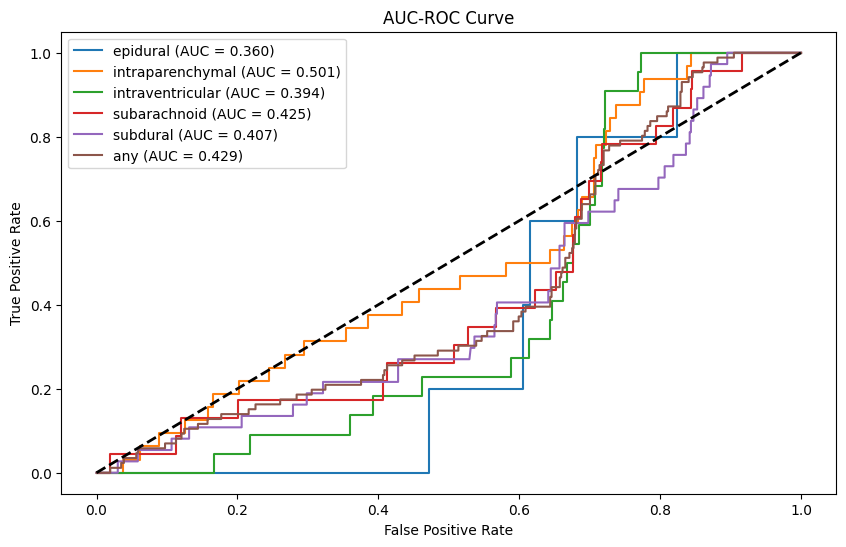

In [14]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

for i, label in enumerate(["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]):
    fpr, tpr, _ = roc_curve(y_val[:, i], effnet_y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()

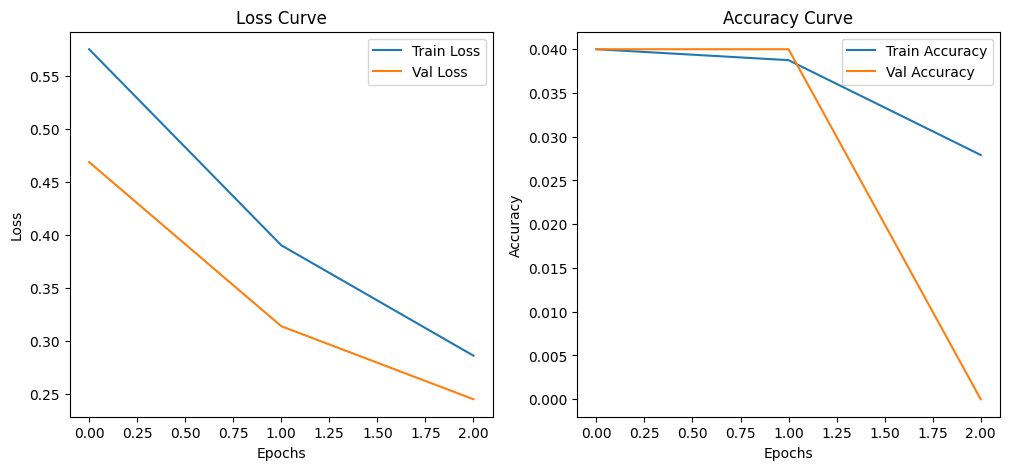

In [15]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score

from sklearn.metrics import classification_report

# Compute metrics for multi-label classification (average='macro' for equal weight to each class)
accuracy = accuracy_score(y_val, effnet_y_pred_binary)
precision = precision_score(y_val, effnet_y_pred_binary, average='macro')
recall = recall_score(y_val, effnet_y_pred_binary, average='macro')
f1 = f1_score(y_val, effnet_y_pred_binary, average='macro')

class_labels = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]
report = classification_report(y_val, effnet_y_pred_binary, target_names=class_labels)
print(report)

# Store training and validation metrics
training_accuracy = history.history['accuracy'][-1]
training_loss = history.history['loss'][-1]
validation_accuracy = history.history['val_accuracy'][-1]
validation_loss = history.history['val_loss'][-1]

# Print metrics using new variables
print(f"Accuracy: {accuracy:.4f}")
print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Training Loss: {training_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")
print(f"Validation Loss: {validation_loss:.4f}")

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")

                  precision    recall  f1-score   support

        epidural       0.00      0.00      0.00         5
intraparenchymal       0.00      0.00      0.00        32
intraventricular       0.00      0.00      0.00        22
    subarachnoid       0.00      0.00      0.00        23
        subdural       0.00      0.00      0.00        37
             any       0.00      0.00      0.00        86

       micro avg       0.00      0.00      0.00       205
       macro avg       0.00      0.00      0.00       205
    weighted avg       0.00      0.00      0.00       205
     samples avg       0.00      0.00      0.00       205

Accuracy: 0.8567
Training Accuracy: 0.0279
Training Loss: 0.2863
Validation Accuracy: 0.0000
Validation Loss: 0.2452
F1 Score: 0.0000
Precision: 0.0000
Recall (Sensitivity): 0.0000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: Unde

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
epidural: No Hemorrhage (0.49)
intraparenchymal: Hemorrhage Detected (0.51)
intraventricular: No Hemorrhage (0.50)
subarachnoid: No Hemorrhage (0.47)
subdural: Hemorrhage Detected (0.52)
any: Hemorrhage Detected (0.51)


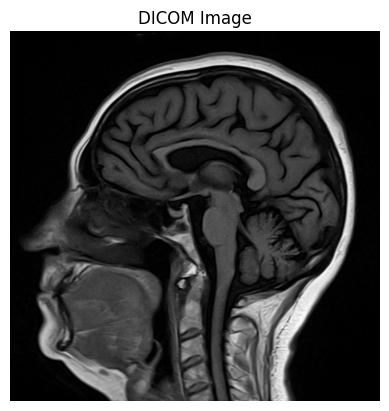

In [20]:
import numpy as np
import pydicom
import os
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("efficientnet_model.h5")

# Define image path
image_path = "/kaggle/input/images/1-1.dcm"

def preprocess_dicom(file_path, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
        img = np.repeat(img, 3, axis=-1)    # Convert grayscale to RGB
        img = img / np.max(img) if np.max(img) > 0 else img  # Normalize
        return np.expand_dims(img, axis=0)  # Add batch dimension
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Preprocess the image
image = preprocess_dicom(image_path)
if image is not None:
    # Predict
    predictions = model.predict(image)[0]
    
    # Define hemorrhage subtypes
    hemorrhage_types = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]
    
    # Print predictions
    for hemorrhage, prob in zip(hemorrhage_types, predictions):
        print(f"{hemorrhage}: {'Hemorrhage Detected' if prob > 0.5 else 'No Hemorrhage'} ({prob:.2f})")
    
    # Display image
    dicom = pydicom.dcmread(image_path)
    plt.imshow(dicom.pixel_array, cmap='gray')
    plt.title("DICOM Image")
    plt.axis("off")
    plt.show()
else:
    print("Failed to process the image.")